# Phase 6: connecting predictive maintenance to the twin

Phase 5 built the skill: given a history of readings, predict how much life a machine has left, checked honestly against data the model never trained on. This phase puts that skill inside the hoist twin itself. The winder gets a health signal that genuinely wears out over time, instead of breaking down at a fixed random rate, and we compare two ways of responding to it. Reactive means fixing the winder only after it actually breaks. Predictive means watching the health signal and stepping in early, before the break happens.

Both policies are run many times under the exact same conditions, and the comparison reports, honestly, what predictive maintenance actually buys in tonnes and downtime. See `phase6_plan.md` for the full reasoning behind every choice made here.

In [1]:
%matplotlib inline
import random
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pdm.evaluate import predicted_vs_true_plot
from twin.maintenance_model import simulate_health_log, train_twin_rul_model
from twin.scenarios import compare_maintenance_policies
from twin.simulation import load_config

config = load_config(str(PROJECT_ROOT / "config.yaml"))
health_cfg = config["winder"]["health"]
health_cfg

/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'mean_life_hours': 200,
 'weibull_shape': 2.5,
 'noise_sd': 3,
 'check_interval_hours': 24,
 'rolling_window': 3,
 'unplanned_repair_mttr_hours': 4,
 'planned_repair_mttr_hours': 2,
 'predictive_lead_time_hours': 24}

## Why the winder needs a real health signal first

The winder's usual breakdown model draws the time until the next failure from an exponential distribution. That distribution is memoryless: knowing the winder has run fine for 50 hours tells you nothing about how soon it will break, the odds are exactly the same as they were on hour one. That is a fine way to model pure bad luck, but it makes prediction pointless, there is nothing to predict.

So this phase gives the winder a health signal instead. Each time it is repaired, it starts a new life, and how long that life lasts is drawn from a Weibull distribution, which genuinely gets riskier the longer a life runs, unlike the exponential. Within a life, true health falls in a straight line from 100 to 0 as the end approaches. Nobody in the simulation sees that true number directly, only a noisy reading of it, taken at a regular interval, the same way a real condition monitoring sensor would be noisy.

6950 readings across 800 simulated lives


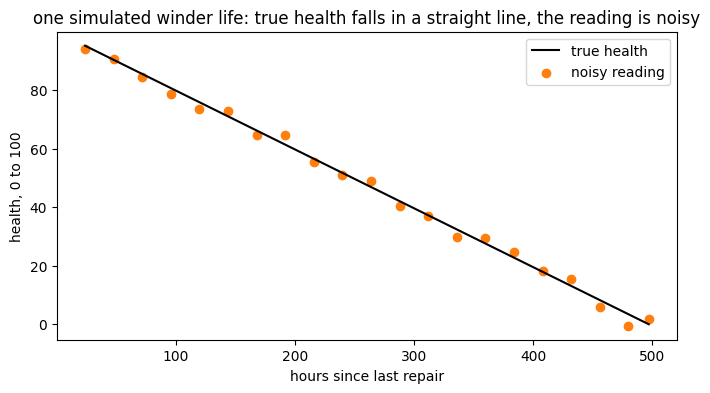

In [2]:
rng = random.Random(1)
log_df = simulate_health_log(health_cfg, n_lives=800, rng=rng)
print(f"{len(log_df)} readings across {log_df['life_id'].nunique()} simulated lives")

# pick a life with plenty of readings, for a clear picture
longest_life_id = log_df.groupby("life_id").size().idxmax()
sample_life = log_df[log_df["life_id"] == longest_life_id]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sample_life["elapsed_hours"], sample_life["true_health"], label="true health", color="black")
ax.scatter(sample_life["elapsed_hours"], sample_life["observed_health"], label="noisy reading", color="tab:orange")
ax.set_xlabel("hours since last repair")
ax.set_ylabel("health, 0 to 100")
ax.set_title("one simulated winder life: true health falls in a straight line, the reading is noisy")
ax.legend()
plt.show()

## Training the twin's own remaining life model

This is the same technique from Phase 5, on a different dataset. Instead of NASA's jet engine sensors, the input here is the twin's own simulated health readings: the current reading, a rolling mean of the last few readings, and hours since the last repair. The model is the same XGBoost regressor Phase 5 already built, reused here directly rather than written again.

Held out by whole life, not by row, so a life's own readings never appear in both training and validation, the same discipline used for engines in Phase 5.

In [3]:
model, X_val, y_val, y_train = train_twin_rul_model(log_df, n_validation_lives=150, seed=42)

pred_val = model.predict(X_val)
rmse = np.sqrt(np.mean((pred_val - y_val.to_numpy()) ** 2))

# a naive baseline that always predicts the training set's mean remaining
# life, so the model's accuracy has something honest to beat
naive_pred = np.full(len(y_val), y_train.mean())
naive_rmse = np.sqrt(np.mean((naive_pred - y_val.to_numpy()) ** 2))

print(f"XGBoost RMSE: {rmse:.1f} hours")
print(f"naive baseline RMSE (always predicts {y_train.mean():.0f} hours): {naive_rmse:.1f} hours")

XGBoost RMSE: 22.0 hours
naive baseline RMSE (always predicts 99 hours): 82.4 hours


## Where the model is accurate, and where it is not

The model clearly beats the naive baseline overall, but the more useful question is whether it is accurate exactly where a maintenance decision would actually use it: when little life is genuinely left. The table below breaks accuracy down by how much true remaining life each reading actually had.

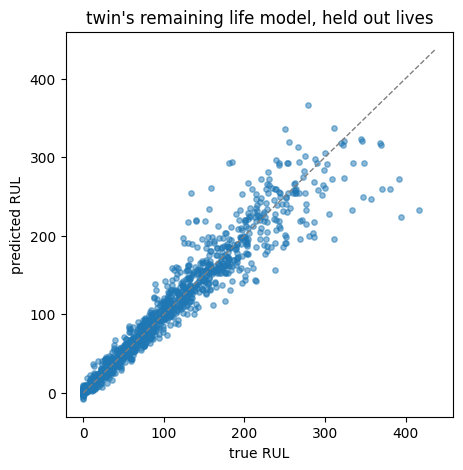

,true remaining hours,rows,RMSE
0,0 to 25,305,4.9
1,25 to 50,150,8.3
2,50 to 100,290,11.1
3,100 to 200,382,23.8
4,200 to 400,166,44.1


In [4]:
predicted_vs_true_plot(y_val, pred_val, title="twin's remaining life model, held out lives")
plt.show()

rows = []
for lo, hi in [(0, 25), (25, 50), (50, 100), (100, 200), (200, 400)]:
    mask = (y_val >= lo) & (y_val < hi)
    if mask.sum() == 0:
        continue
    bucket_rmse = np.sqrt(np.mean((pred_val[mask.to_numpy()] - y_val[mask].to_numpy()) ** 2))
    rows.append({"true remaining hours": f"{lo} to {hi}", "rows": int(mask.sum()), "RMSE": round(bucket_rmse, 1)})
pd.DataFrame(rows)

Accuracy is best exactly where it matters most, close to failure, and gets looser further out, where a maintenance decision would not be made anyway. Unlike the LSTM in Phase 5, this model does not collapse to a flat average guess for readings still far from failure, most likely because elapsed hours since the last repair is itself a genuinely useful clue here, not just the health reading alone.

## Comparing reactive and predictive maintenance

Reactive means the winder only gets repaired once it actually breaks. Predictive means a trained model watches the noisy health reading and steps in early, with a shorter planned repair, once its predicted remaining life drops under a chosen lead time (24 hours here, see `phase6_plan.md`).

Both policies are run many times, using the same underlying randomness for corresponding runs of each, so the comparison mostly reflects the policy itself rather than unrelated random noise. Once the predictive policy first steps in early on some life, that life ends sooner than it would have reactively, so the next life's draw happens at a different point in time from there in each run. That is expected, it is exactly the decision being measured, not a flaw in the comparison, and averaging over many runs still gives a fair answer.

In [5]:
comparison = compare_maintenance_policies(config, predictive_model=model, n_replications=20, base_seed=200)
comparison

,mean_monthly_tonnes,ci_low,ci_high,mean_annual_tonnes,mean_breakdown_count,mean_planned_predictive_count,mean_scheduled_hours,mean_breakdown_hours,mean_planned_predictive_hours,mean_total_downtime_hours,paired_annual_tonnes_diff_vs_reactive,paired_tonnes_diff_ci_low,paired_tonnes_diff_ci_high,paired_tonnes_diff_p_value,paired_downtime_hours_diff_vs_reactive,paired_downtime_diff_ci_low,paired_downtime_diff_ci_high,paired_downtime_diff_p_value
policy,,,,,,,,,,,,,,,,,,
reactive,237089.9,236621.416536,237558.383464,2845078.8,42.4,0.0,260.0,170.57903,0.000000,430.579030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
predictive,239335.6,239141.506434,239529.693566,2872027.2,0.0,45.2,260.0,0.00000,90.485101,350.485101,26948.4,21233.910189,32662.889811,6.492241e-09,-80.093928,-96.606707,-63.58115,4.125021e-09


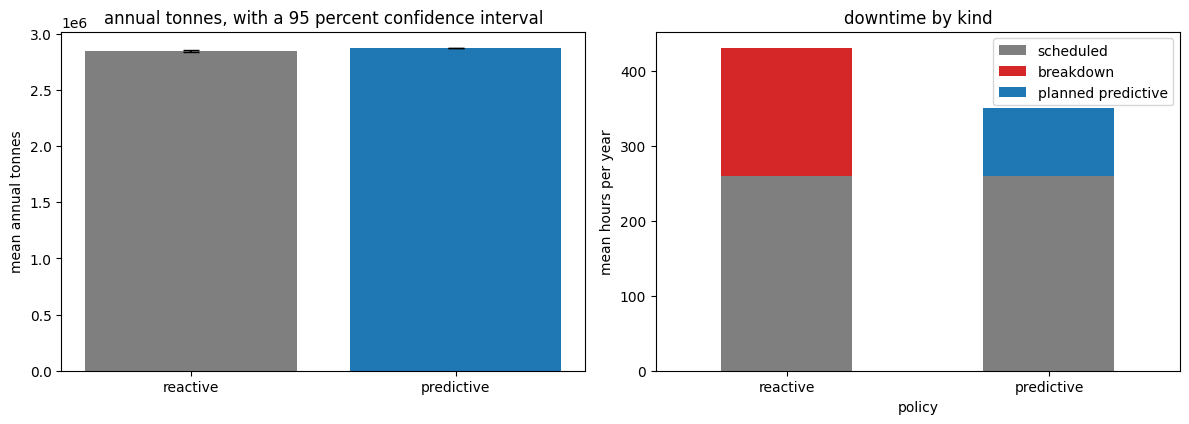

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    comparison.index,
    comparison["mean_annual_tonnes"],
    yerr=[
        comparison["mean_annual_tonnes"] - comparison["ci_low"] * 12,
        comparison["ci_high"] * 12 - comparison["mean_annual_tonnes"],
    ],
    capsize=6,
    color=["tab:gray", "tab:blue"],
)
axes[0].set_ylabel("mean annual tonnes")
axes[0].set_title("annual tonnes, with a 95 percent confidence interval")

# downtime by kind, read directly from the comparison table above, no need
# to run the simulation again to get it
downtime_cols = ["mean_scheduled_hours", "mean_breakdown_hours", "mean_planned_predictive_hours"]
downtime_table = comparison[downtime_cols].rename(
    columns=lambda c: c.replace("mean_", "").replace("_hours", "").replace("_", " ")
)
downtime_table.plot(kind="bar", stacked=True, ax=axes[1], color=["tab:gray", "tab:red", "tab:blue"])
axes[1].set_ylabel("mean hours per year")
axes[1].set_title("downtime by kind")
axes[1].legend(title="")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## What this phase actually found

**Predictive maintenance wins here, and by a real margin, not a lucky run.** Across 20 replications of each policy, sharing the same underlying randomness, predictive maintenance produced more annual tonnes than reactive, and the paired confidence interval for that difference stays clearly above zero, this is not noise.

**The reason is visible directly in the downtime chart.** Reactive racks up real breakdowns, each needing a longer unplanned repair. Predictive trades most of that away for shorter planned repairs, taken before the winder actually fails, cutting total downtime.

**The model earns this by being accurate exactly where it needs to be.** It is not perfect far from failure, and it does not need to be, nobody would act on a warning that far out anyway. Close to failure, where the maintenance decision actually gets made, it is accurate enough to catch the large majority of cases before they become a real breakdown.

**What carries forward to Phase 7.** This is the standout result of the whole project: a twin that does not just simulate the hoist circuit, it demonstrates a concrete, quantified business case for predictive maintenance, produced honestly from the twin's own numbers rather than asserted. Phase 7 makes this usable by someone who is not reading code: a dashboard exposing the surrogate model from Phase 3 and 4, and a remaining life prediction like the one built here and in Phase 5.